# 📊 Khám phá Dữ liệu (Exploratory Data Analysis - EDA)
Notebook này giúp nhóm có cái nhìn tổng quan về bộ dữ liệu PlantVillage trước khi bắt tay vào train mô hình. Các biểu đồ ở đây rất hữu ích để đưa vào báo cáo Word (Phần II).

In [6]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

## 1. Kiểm tra phân phối Dữ liệu
Để biết được dữ liệu có bị mất cân bằng (Imbalanced Data) hay không.

In [7]:
# Đường dẫn đến thư mục data
data_dir = '../data/train'

if not os.path.exists(data_dir):
    print("Lỗi: Đường dẫn ../data/train không tồn tại. Vui lòng chạy file src/data_prep.py trước để tải dữ liệu.")
else:
    class_names = os.listdir(data_dir)
    class_counts = {}
    
    for cls in class_names:
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    
    print(f"Tổng số lớp (Class): {len(class_counts)}")
    print(f"Tổng số ảnh trong tập train: {sum(class_counts.values())}")

Tổng số lớp (Class): 38
Tổng số ảnh trong tập train: 37998


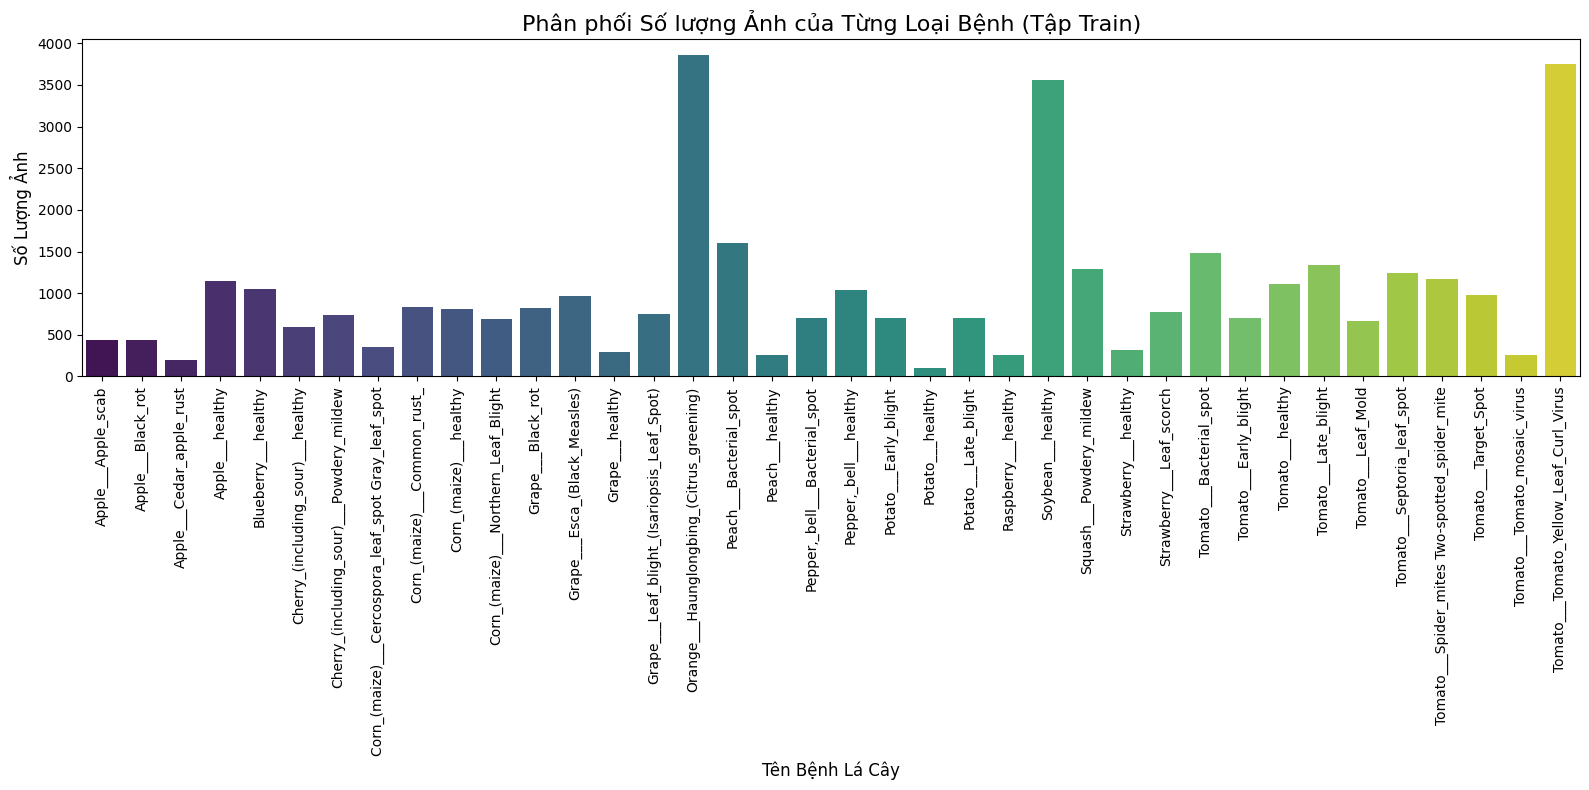

In [8]:
if os.path.exists(data_dir):
    plt.figure(figsize=(16, 8))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Phân phối Số lượng Ảnh của Từng Loại Bệnh (Tập Train)', fontsize=16)
    plt.xlabel('Tên Bệnh Lá Cây', fontsize=12)
    plt.ylabel('Số Lượng Ảnh', fontsize=12)
    plt.tight_layout()
    plt.show()

## 2. Trực quan hóa Ảnh thực tế
Hiển thị ngẫu nhiên các ảnh để quan sát màu sắc và cấu trúc của lá cây bị bệnh.

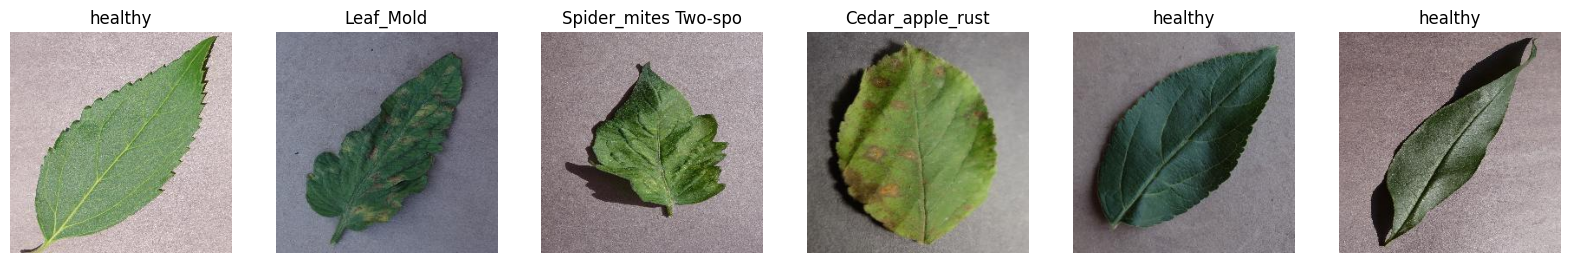

In [9]:
def plot_random_samples(data_dir, num_samples=5):
    plt.figure(figsize=(20, 5))
    classes = np.random.choice(class_names, num_samples, replace=False)
    
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        img_name = np.random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        # Cắt tên bệnh cho ngắn gọn
        short_name = cls.split('___')[-1][:20]
        plt.title(short_name, fontsize=12)
        plt.axis('off')
    plt.show()

if os.path.exists(data_dir):
    plot_random_samples(data_dir, 6)

## 3. Kiểm tra kích thước ảnh gốc
Bước này giúp chúng ta biết cần thiết lập tiền xử lý Data Augmentation (trong kịch bản train) là bao nhiêu.

In [10]:
if os.path.exists(data_dir):
    sample_cls = class_names[0]
    sample_img_path = os.path.join(data_dir, sample_cls, os.listdir(os.path.join(data_dir, sample_cls))[0])
    img = cv2.imread(sample_img_path)
    print(f"Kích thước ảnh đầu vào gốc (Width, Height, Channels): {img.shape}")
    print("Lưu ý: Khi đưa vào mô hình, nên resize về (224, 224, 3) để đồng bộ hóa.")

Kích thước ảnh đầu vào gốc (Width, Height, Channels): (256, 256, 3)
Lưu ý: Khi đưa vào mô hình, nên resize về (224, 224, 3) để đồng bộ hóa.
